## COMPAS - 3 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals and Regularization coefficient

### Methods

* **ML_MOO**
* **MONISE**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils.extmath import squared_norm

from ml_moo import MooScalarization

### Dataset and Model

In [3]:
# Setting a seed for reproducibility
seed = 42

In [4]:
data = pd.read_csv("dataset/compas_onerace.csv")
fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"
data = data.drop("Unnamed: 0", axis=1)

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X_all = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y_all = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


In [5]:
#tol = 10**-3
#max_iter = 100

tol = 10**-3
max_iter = 100

In [6]:
lambd = math.exp(-100)

clf = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           max_iter = max_iter,
                           tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

In [7]:
def train_logreg_fair(model, X, y, fair_feat, fair_att, w):
    """
    Treina o modelo com sample weights balanceadas por grupo de fairness.
    Retorna a loss por grupo.
    """
    # Gera os sample_weights com base nos grupos
    if w[-1] == 0:
        lambd = 10**-20
    elif w[-1] == 1:
        lambd = 10**20
    else:
        lambd = w[-1]/(1-w[-1])

    fair_weight = w[:-1]*(1+lambd)
    
    fair_weight = w
    sample_weight = X[fair_feat].replace({ff:fw/sum(X[fair_feat]==ff) 
                                    for ff, fw in zip(fair_att,fair_weight)})

    # Treina o modelo
    model.C = 1/lambd
    model.fit(X, y, sample_weight=sample_weight.to_numpy())

    # Avaliação: log_loss por grupo
    y_pred = model.predict_proba(X)
    objs = np.zeros(len(fair_att) + 1)
    for i, feat in enumerate(fair_att):
        fair_weight = np.zeros(len(fair_att))
        fair_weight[i] = 1
        sample_weight = X[fair_feat].replace({ff:fw for ff, fw in zip(fair_att,fair_weight)}) 
        objs[i] = log_loss(y, y_pred, sample_weight=sample_weight)
    objs[-1] = squared_norm(model.coef_)
    return objs, model, None

In [8]:
fair_feat = fair_feature
fair_att = sorted(X_all[fair_feat].unique())

# Train function to be passed in scalarization
def train_fn_logreg(clf, w):
    return train_logreg_fair(clf, X_train, y_train, fair_feat, fair_att, w)

## Multi Objective Optimization Process

In [9]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 3

In [10]:
# Logistic Regression with equal weight to use as baseline
equal = MooScalarization(clf, train_fn_logreg, num_objs)
equal.optimize(np.array([1/3, 1/3, 1/3]))

In [11]:
methods = [
    'mola', 
    'monise', 
    'random_weight'
    ]

results = {}

In [12]:
from ml_moo import moo
from ml_moo import MooScalarization
from ml_moo.scalarization.three_objs_fairness_logreg import LogRegFairScalarization
from ml_moo.analysis.visualization import plot_pareto_3d
from ml_moo.analysis.metrics import compute_hypervolume_progress
from ml_moo import get_objectives

In [13]:
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)

09:59:32 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
09:59:32 | DEBUG | ml_moo | Finding 1th individual minimum
09:59:32 | DEBUG | ml_moo | Finding 2th individual minimum
09:59:32 | DEBUG | ml_moo | Finding 3th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/s

new solution added [0.61500891 0.61790136 0.80683347]
new solution added [0.6127796  0.61900695 0.92608075]
new solution added [0.61464031 0.62140937 0.60444461]


09:59:32 | DEBUG | ml_moo | Calculated weights: [0.         0.98018818 0.01981182]
09:59:32 | DEBUG | ml_moo | Importance: 0.002473039526382892
09:59:32 | DEBUG | ml_moo | Global lower bound (y*): [0.61244504 0.61659474 0.60444461]
09:59:32 | DEBUG | ml_moo | Iteration 4
09:59:32 | DEBUG | ml_moo | Solutions list: [array([0.61464031, 0.62140937, 0.60444461]), array([0.6127796 , 0.61900695, 0.92608075]), array([0.61500891, 0.61790136, 0.80683347]), array([0.61244504, 0.6185856 , 1.16925224]), array([0.6144886 , 0.61659474, 1.34358712]), array([0.6144886 , 0.61659474, 1.34358712])]
09:59:32 | DEBUG | ml_moo | Calculated weights: [4.82923143e-05 8.11233843e-01 1.88717864e-01]
09:59:32 | DEBUG | ml_moo | Importance: 0.001756622925719542
09:59:32 | DEBUG | ml_moo | Global lower bound (y*): [0.61244504 0.61659474 0.60444461]
09:59:32 | DEBUG | ml_moo | Iteration 5
09:59:32 | DEBUG | ml_moo | Solutions list: [array([0.61630282, 0.61938334, 0.61315339]), array([0.61464031, 0.62140937, 0.604444

new solution added [0.61630282 0.61938334 0.61315339]
new solution added [0.6372679  0.63619329 0.05034675]
new solution added [0.61810627 0.62580124 0.35832156]


09:59:33 | DEBUG | ml_moo | Calculated weights: [0.9414262 0.        0.0585738]
09:59:33 | DEBUG | ml_moo | Importance: 0.018305736332665967
09:59:33 | DEBUG | ml_moo | Global lower bound (y*): [0.61244504 0.61659474 0.05034675]
09:59:33 | DEBUG | ml_moo | Iteration 7
09:59:33 | DEBUG | ml_moo | Solutions list: [array([0.61810627, 0.62580124, 0.35832156]), array([0.6372679 , 0.63619329, 0.05034675]), array([0.61630282, 0.61938334, 0.61315339]), array([0.61464031, 0.62140937, 0.60444461]), array([0.6127796 , 0.61900695, 0.92608075]), array([0.61500891, 0.61790136, 0.80683347]), array([0.61244504, 0.6185856 , 1.16925224]), array([0.6144886 , 0.61659474, 1.34358712]), array([0.6144886 , 0.61659474, 1.34358712])]
09:59:33 | DEBUG | ml_moo | Calculated weights: [0.92195018 0.         0.07804982]
09:59:33 | DEBUG | ml_moo | Importance: 0.015384690316027294
09:59:33 | DEBUG | ml_moo | Global lower bound (y*): [0.61244504 0.61659474 0.05034675]
09:59:33 | DEBUG | ml_moo | Iteration 8
09:59:33 

...

new solution dominated [0.62358984 0.63200138 0.17166032]
new solution dominated [0.62358984 0.63200138 0.17166032]


09:59:39 | DEBUG | ml_moo | Calculated weights: [0.92065975 0.         0.07934025]
09:59:39 | DEBUG | ml_moo | Importance: 0.003592736926579465
09:59:39 | DEBUG | ml_moo | Global lower bound (y*): [0.61244504 0.61659474 0.01553703]
09:59:39 | DEBUG | ml_moo | Iteration 48
09:59:39 | DEBUG | ml_moo | Solutions list: [array([0.62359012, 0.63200169, 0.17165385]), array([0.62358984, 0.63200138, 0.17166032]), array([0.62004989, 0.62273906, 0.37141825]), array([0.61885867, 0.62177009, 0.42611978]), array([0.64667854, 0.64339488, 0.01553703]), array([0.64061167, 0.63913901, 0.03029199]), array([0.63736053, 0.64786604, 0.02112855]), array([0.61751156, 0.62077223, 0.49433443]), array([0.63072875, 0.63979866, 0.06132644]), array([0.627791  , 0.63627982, 0.09541594]), array([0.62567523, 0.63419439, 0.12894893]), array([0.62342974, 0.63174119, 0.1754064 ]), array([0.62100898, 0.62903168, 0.24240248]), array([0.61810627, 0.62580124, 0.35832156]), array([0.6372679 , 0.63619329, 0.05034675]), array([

new solution dominated [0.62358984 0.63200138 0.17166032]
new solution dominated [0.62358984 0.63200138 0.17166032]


09:59:39 | DEBUG | ml_moo | Calculated weights: [0.92065975 0.         0.07934025]
09:59:39 | DEBUG | ml_moo | Importance: 0.003592736926579465
09:59:39 | DEBUG | ml_moo | Global lower bound (y*): [0.61244504 0.61659474 0.01553703]
09:59:39 | DEBUG | ml_moo | Iteration 50
09:59:39 | DEBUG | ml_moo | Solutions list: [array([0.62359012, 0.63200169, 0.17165385]), array([0.62358984, 0.63200138, 0.17166032]), array([0.62004989, 0.62273906, 0.37141825]), array([0.61885867, 0.62177009, 0.42611978]), array([0.64667854, 0.64339488, 0.01553703]), array([0.64061167, 0.63913901, 0.03029199]), array([0.63736053, 0.64786604, 0.02112855]), array([0.61751156, 0.62077223, 0.49433443]), array([0.63072875, 0.63979866, 0.06132644]), array([0.627791  , 0.63627982, 0.09541594]), array([0.62567523, 0.63419439, 0.12894893]), array([0.62342974, 0.63174119, 0.1754064 ]), array([0.62100898, 0.62903168, 0.24240248]), array([0.61810627, 0.62580124, 0.35832156]), array([0.6372679 , 0.63619329, 0.05034675]), array([

new solution dominated [0.62358984 0.63200138 0.17166032]


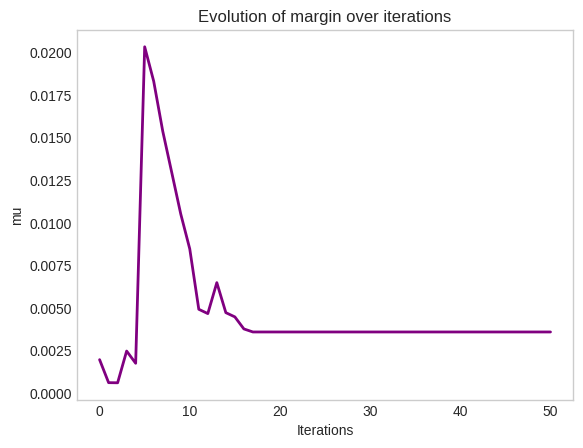

09:59:40 | INFO | ml_moo | Fit runtime: 7.58 seconds


In [14]:
method = 'mola'
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)
moopt = moo(scalarization).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

In [15]:
objs_all = np.array([s.objs for s in moopt.history_list])

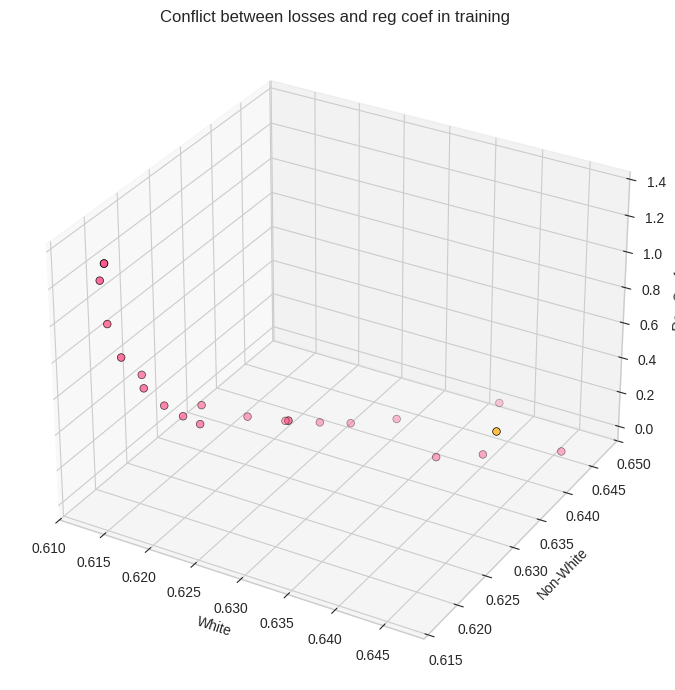

In [16]:
title = "Conflict between losses and reg coef in training"
plot_pareto_3d(objs,
               labels=("White", "Non-White", "Reg Coef"), 
               title=title,
               point = equal.objs,
               color="#FF5C8D")

In [ ]:
method = 'mola'
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)
moopt = moo(scalarization).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

In [ ]:
title = "2 Conflict between losses and reg coef in training"
plot_pareto_3d(objs,
               labels=("White", "Non-White", "Reg Coef"), 
               title=title,
               point = equal.objs,
               color="#FF5C8D")

In [17]:
w_scalar = MooScalarization(clf, train_fn_logreg, num_objs)

09:59:40 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
09:59:40 | DEBUG | ml_moo | Finding 1th individual minimum
09:59:40 | DEBUG | ml_moo | Finding 2th individual minimum
09:59:40 | DEBUG | ml_moo | Finding 3th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/s

new solution added [0.61489075 0.61780014 0.82496083]
new solution added [0.61278583 0.61902136 0.92389652]
new solution added [0.61510225 0.62199592 0.55877582]


09:59:40 | DEBUG | ml_moo | Calculated weights: [0.         0.98448195 0.01551805]
09:59:40 | DEBUG | ml_moo | Importance: 0.003047854523753668
09:59:40 | DEBUG | ml_moo | Global lower bound (y*): [0.61244734 0.61659468 0.55877582]
09:59:40 | DEBUG | ml_moo | Iteration 4
09:59:40 | DEBUG | ml_moo | Solutions list: [array([0.61510225, 0.62199592, 0.55877582]), array([0.61278583, 0.61902136, 0.92389652]), array([0.61489075, 0.61780014, 0.82496083]), array([0.61244734, 0.61846327, 1.17184019]), array([0.61451833, 0.61659468, 1.34488401]), array([0.61451833, 0.61659468, 1.34488401])]
09:59:40 | DEBUG | ml_moo | Calculated weights: [7.37831602e-05 9.75767181e-01 2.41590359e-02]
09:59:40 | DEBUG | ml_moo | Importance: 0.003020840965684113
09:59:40 | DEBUG | ml_moo | Global lower bound (y*): [0.61244734 0.61659468 0.55877582]
09:59:40 | DEBUG | ml_moo | Iteration 5
09:59:40 | DEBUG | ml_moo | Solutions list: [array([0.61572017, 0.61868022, 0.69269273]), array([0.61510225, 0.62199592, 0.558775

new solution added [0.61572017 0.61868022 0.69269273]
new solution added [0.61734924 0.620384   0.52294993]
new solution added [0.62154203 0.62954552 0.2257985 ]


09:59:41 | DEBUG | ml_moo | Calculated weights: [0.04541841 0.92540932 0.02917227]
09:59:41 | DEBUG | ml_moo | Importance: 0.007257040895806033
09:59:41 | DEBUG | ml_moo | Global lower bound (y*): [0.61244734 0.61659468 0.2257985 ]
09:59:41 | DEBUG | ml_moo | Iteration 7
09:59:41 | DEBUG | ml_moo | Solutions list: [array([0.62154203, 0.62954552, 0.2257985 ]), array([0.61734924, 0.620384  , 0.52294993]), array([0.61572017, 0.61868022, 0.69269273]), array([0.61510225, 0.62199592, 0.55877582]), array([0.61278583, 0.61902136, 0.92389652]), array([0.61489075, 0.61780014, 0.82496083]), array([0.61244734, 0.61846327, 1.17184019]), array([0.61451833, 0.61659468, 1.34488401]), array([0.61451833, 0.61659468, 1.34488401])]
09:59:41 | DEBUG | ml_moo | Calculated weights: [0.         0.96478373 0.03521627]
09:59:41 | DEBUG | ml_moo | Importance: 0.007544282139153147
09:59:41 | DEBUG | ml_moo | Global lower bound (y*): [0.61244734 0.61659468 0.2257985 ]
09:59:41 | DEBUG | ml_moo | Iteration 8
09:59:

...

new solution dominated [0.62591645 0.62695586 0.20739517]
new solution dominated [0.62591645 0.62695586 0.20739517]


09:59:47 | DEBUG | ml_moo | Calculated weights: [0.         0.93887163 0.06112837]
09:59:47 | DEBUG | ml_moo | Importance: 0.003653165743773279
09:59:47 | DEBUG | ml_moo | Global lower bound (y*): [0.61244734 0.61659468 0.02904723]
09:59:47 | DEBUG | ml_moo | Iteration 48
09:59:47 | DEBUG | ml_moo | Solutions list: [array([0.62591645, 0.62695586, 0.20739517]), array([0.62579196, 0.62696   , 0.20724023]), array([0.62579164, 0.62696   , 0.20724032]), array([0.62579197, 0.62696   , 0.20724023]), array([0.64036226, 0.63860789, 0.03317138]), array([0.63538089, 0.64534089, 0.02904723]), array([0.63475606, 0.63425082, 0.06965204]), array([0.62929306, 0.62988103, 0.13676773]), array([0.6281706 , 0.63698462, 0.09026992]), array([0.62571513, 0.62742736, 0.19441262]), array([0.6218615 , 0.62419876, 0.30333538]), array([0.61992388, 0.6226426 , 0.37648157]), array([0.61833719, 0.62141985, 0.44840903]), array([0.62154203, 0.62954552, 0.2257985 ]), array([0.61734924, 0.620384  , 0.52294993]), array([

new solution dominated [0.62591645 0.62695586 0.20739517]
new solution dominated [0.62591645 0.62695586 0.20739517]


09:59:47 | DEBUG | ml_moo | Calculated weights: [0.         0.93887163 0.06112837]
09:59:47 | DEBUG | ml_moo | Importance: 0.003653165743773279
09:59:47 | DEBUG | ml_moo | Global lower bound (y*): [0.61244734 0.61659468 0.02904723]
09:59:47 | DEBUG | ml_moo | Iteration 50
09:59:47 | DEBUG | ml_moo | Solutions list: [array([0.62591645, 0.62695586, 0.20739517]), array([0.62579196, 0.62696   , 0.20724023]), array([0.62579164, 0.62696   , 0.20724032]), array([0.62579197, 0.62696   , 0.20724023]), array([0.64036226, 0.63860789, 0.03317138]), array([0.63538089, 0.64534089, 0.02904723]), array([0.63475606, 0.63425082, 0.06965204]), array([0.62929306, 0.62988103, 0.13676773]), array([0.6281706 , 0.63698462, 0.09026992]), array([0.62571513, 0.62742736, 0.19441262]), array([0.6218615 , 0.62419876, 0.30333538]), array([0.61992388, 0.6226426 , 0.37648157]), array([0.61833719, 0.62141985, 0.44840903]), array([0.62154203, 0.62954552, 0.2257985 ]), array([0.61734924, 0.620384  , 0.52294993]), array([

new solution dominated [0.62591645 0.62695586 0.20739517]


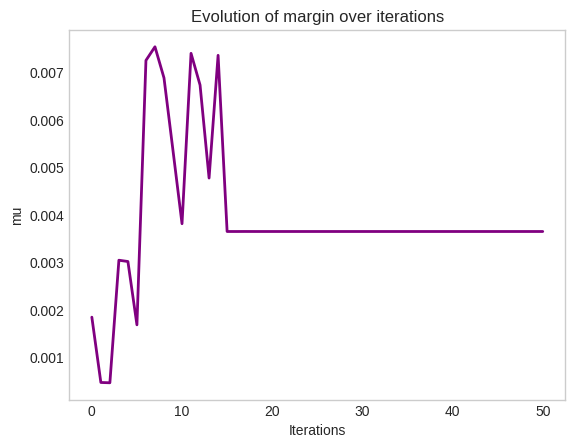

09:59:47 | INFO | ml_moo | Fit runtime: 7.45 seconds


In [18]:
method = 'mola'
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

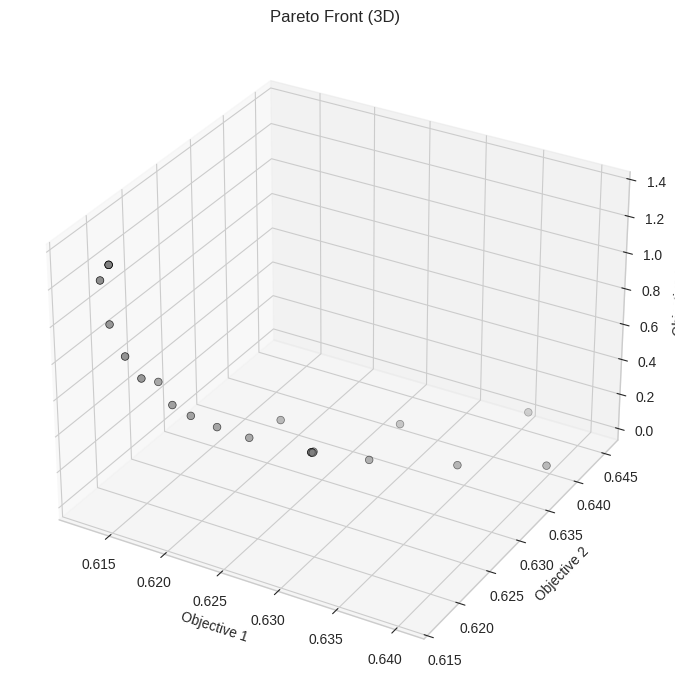

In [19]:
plot_pareto_3d(objs)

### MONISE

In [20]:
w_scalar = MooScalarization(clf, train_fn_logreg, num_objs)
method = 'monise'
moopt_monise = moo(scalarization).mo_optimization(method, **opt_params)
objs = get_objectives(moopt_monise)
hypervolume_values = compute_hypervolume_progress(objs)
#hypervolume_values = moopt_monise.get_hypervolumes()
results[method] = {
                "moopt": moopt_monise,
                "objectives": objs,
                "models": moopt_monise.get_models() if hasattr(moopt_monise, "get_models") else None,
                "hypervolume": hypervolume_values
            }

09:59:48 | DEBUG | ml_moo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 300, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
09:59:48 | DEBUG | ml_moo.moo.monise | Finding 1th individual minima
09:59:48 | DEBUG | ml_moo.moo.monise | Finding 2th individual minima
09:59:48 | DEBUG | ml_moo.moo.monise | Finding 3th individual minima


monise


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver optio

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


09:59:49 | DEBUG | ml_moo.moo.monise | 10th solution - importance: 0.13543199576025766
09:59:49 | DEBUG | ml_moo.moo.monise | 11th solution - importance: 0.12738679899113095
09:59:49 | DEBUG | ml_moo.moo.monise | 12th solution - importance: 0.03454127940750083
09:59:49 | DEBUG | ml_moo.moo.monise | 13th solution - importance: 0.03431809947714328
09:59:49 | DEBUG | ml_moo.moo.monise | 14th solution - importance: 0.03307912350040376


...

10:00:43 | DEBUG | ml_moo.moo.monise | 130th solution - importance: 0.0007322369289225825


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


10:00:44 | DEBUG | ml_moo.moo.monise | 131th solution - importance: 0.0007322369289225825


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


KeyboardInterrupt: 

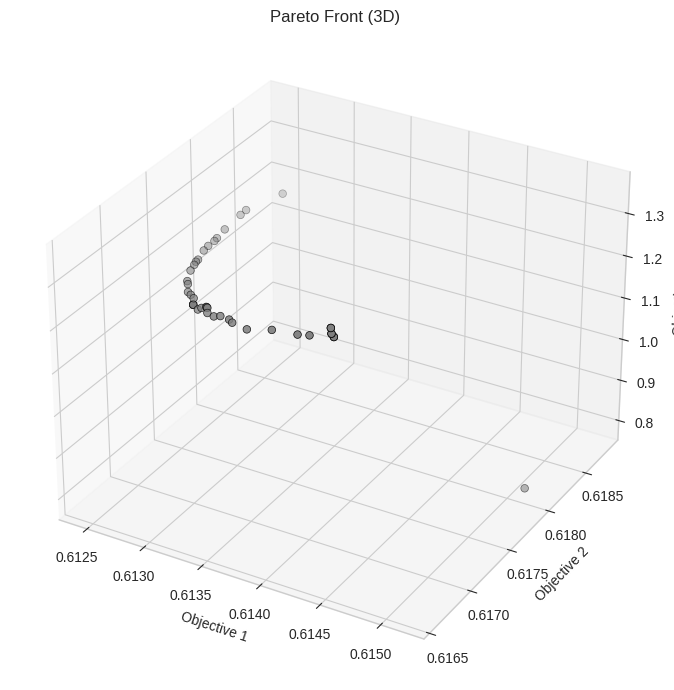

In [ ]:
objs = get_objectives(moopt_monise)
plot_pareto_3d(objs)

### Ramdon Weighted Sum

In [ ]:
w_scalar = MooScalarization(clf, train_fn_logreg, num_objs)
method = 'random_weight'
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
#hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

23:55:17 | WARNING | ml_moo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
23:55:17 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
23:55:17 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
23:55:17 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima
23:55:17 | DEBUG | ml_moo.moo.random_weights | Finding 3th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid

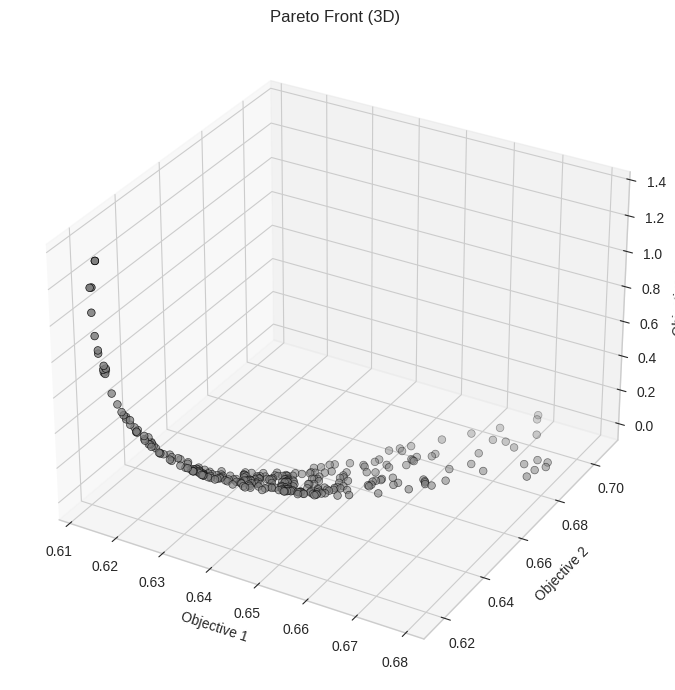

In [ ]:
objs = get_objectives(moopt)
plot_pareto_3d(objs)

## Comparison between MOO methods

In [ ]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

In [ ]:
# experiment_results, pareto_dict, hypervolumes_dic = run_experiments(
#                                                             methods = methods,
#                                                             opt_params = opt_params,
#                                                             model = clf,
#                                                             train_fn = train_fn_logreg,
#                                                             num_objs = num_objs,
#                                                             mola_hv = False
#                                                             )

In [ ]:
#experiment_results

00:02:29 | WARNING | ml_moo | [Methods have different numbers of solutions: {18, 42, 300}


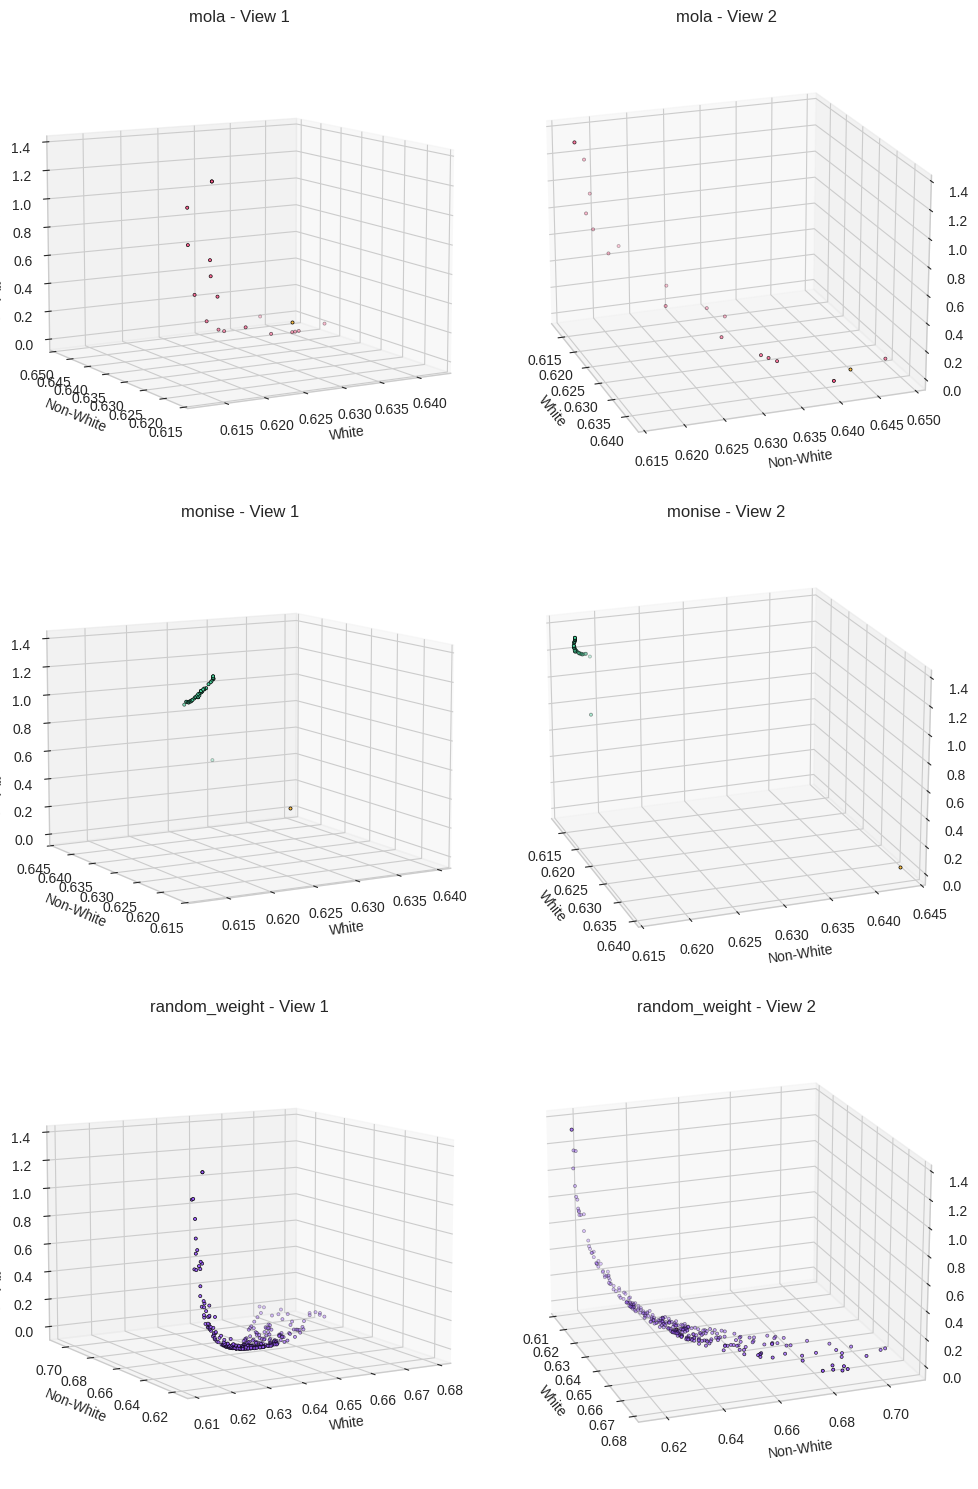

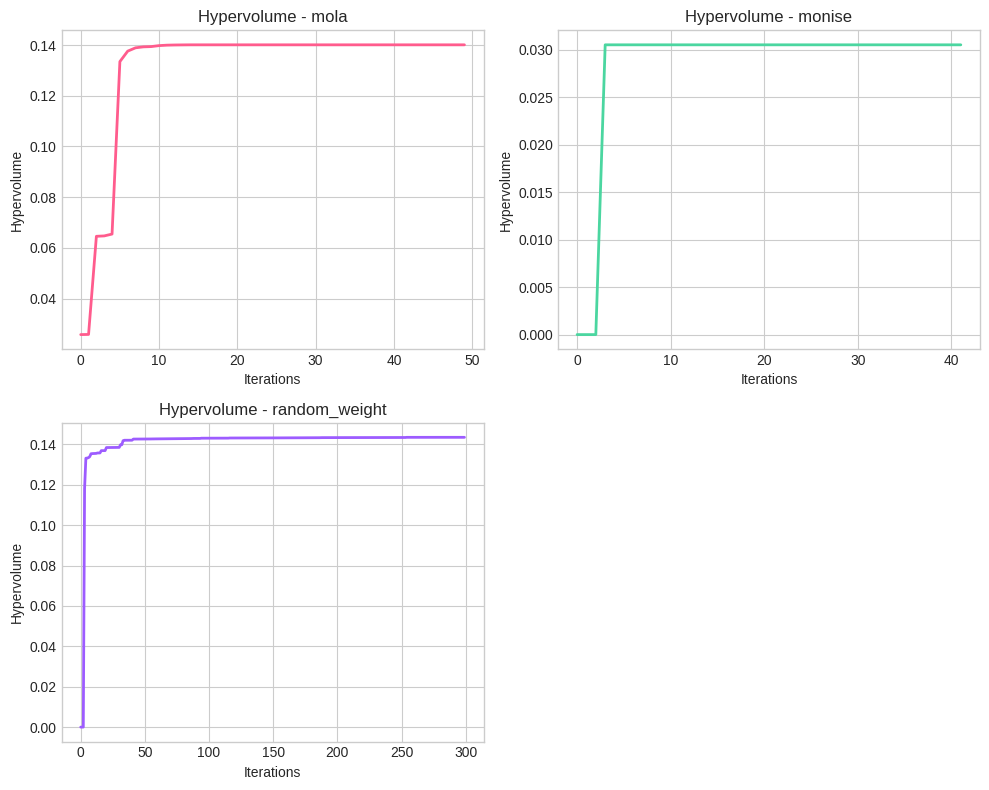

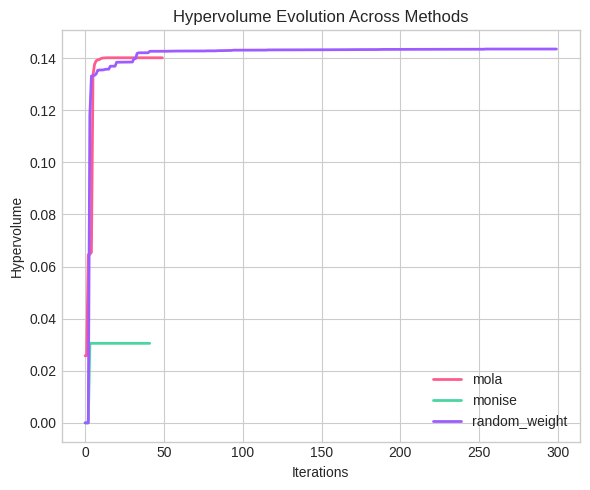

00:02:30 | WARNING | ml_moo | [Methods have different numbers of solutions: {18, 42, 300}


[Analyzer] Visualization complete.


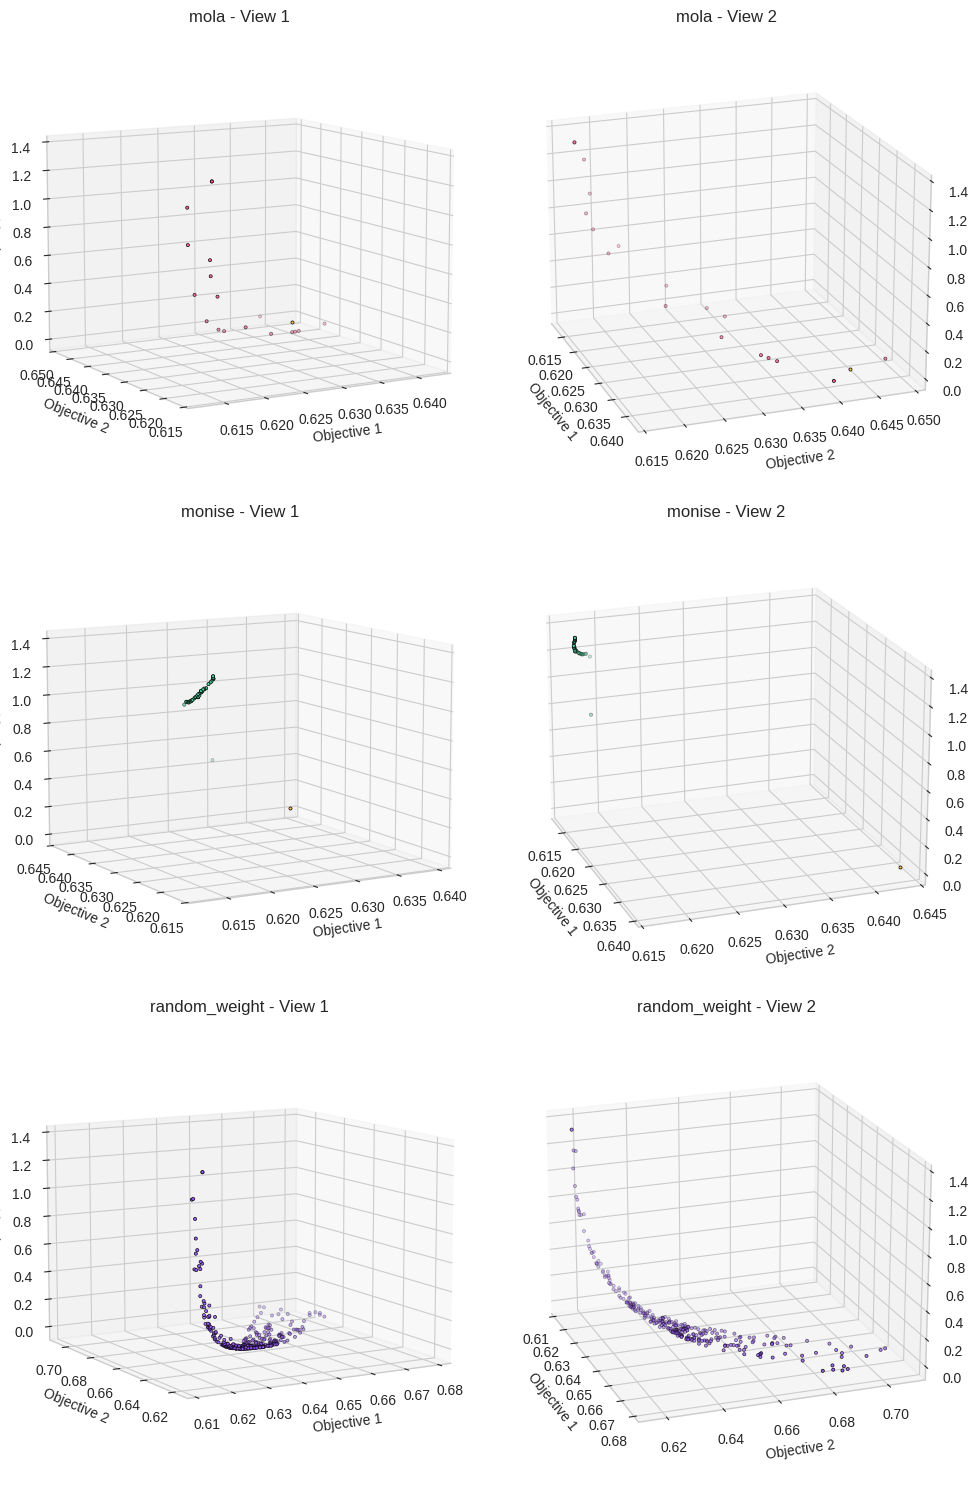

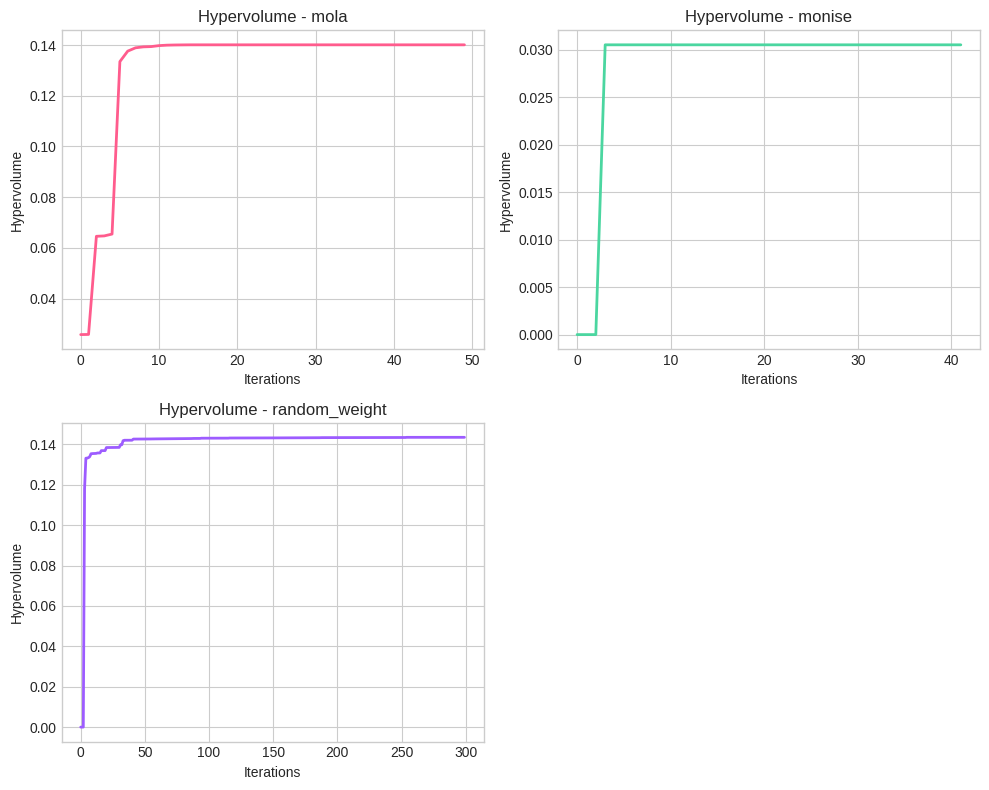

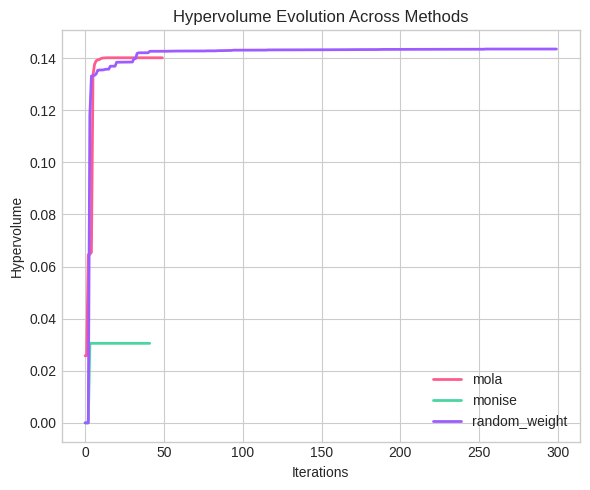

[Analyzer] Visualization complete.


In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["White", "Non-White", "Regularization coefficient"]

Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal.objs,
                      axis_label=axis_label,
                      #num_views = 3,
                      )


title = ""
axis_label = ["White", "Non-White"]
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal.objs
                      )